# PSF на простых примерах

Этот ноутбук не выполняет астрометрию реальных кадров. Его задача — визуально показать:

1. что такое идеальный точечный источник;
2. почему звезда на снимке выглядит пятном;
3. как по звёздам измеряется PSF;
4. как PSF помогает найти центр слабого астероида;
5. почему движущийся астероид перед сложением нужно сдвигать.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import shift
from scipy.optimize import least_squares
from scipy.signal import fftconvolve

plt.rcParams.update({
    "figure.figsize": (11, 4),
    "image.cmap": "magma",
})
rng = np.random.default_rng(7065)

## 1. Идеальная точка и реальное изображение

Далёкая звезда имеет настолько малый угловой размер, что для нашей камеры является точкой. Но камера не может записать бесконечно маленькую точку в один пиксель: атмосфера, дифракция, расфокусировка и размер пикселей распределяют свет по соседним пикселям.

Изображение, которое система создаёт из одной идеальной точки, и называется **PSF — Point Spread Function**, или **функция рассеяния точки**.

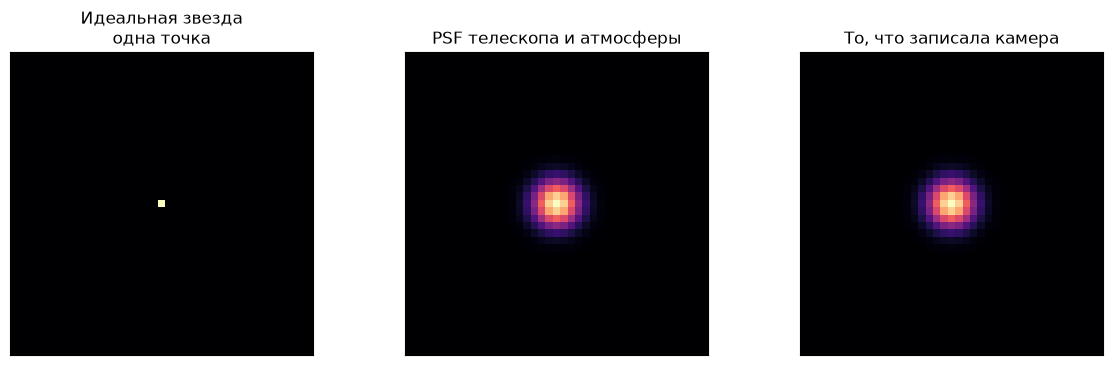

In [2]:
size = 41
y, x = np.indices((size, size))
center = (size - 1) / 2

ideal_point = np.zeros((size, size))
ideal_point[int(center), int(center)] = 1

sigma = 2.2
psf = np.exp(-0.5 * ((x - center)**2 + (y - center)**2) / sigma**2)
psf /= psf.sum()

recorded_star = fftconvolve(ideal_point, psf, mode="same")

fig, axes = plt.subplots(1, 3, figsize=(12, 3.7))
images = [ideal_point, psf, recorded_star]
titles = [
    "Идеальная звезда\nодна точка",
    "PSF телескопа и атмосферы",
    "То, что записала камера",
]
for ax, image, title in zip(axes, images, titles):
    ax.imshow(image, origin="lower")
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])
plt.tight_layout()
plt.show()

В данном простом примере изображение звезды и PSF совпадают. Математически это записывается так:

\[
\text{изображение} = \text{идеальный объект} * \text{PSF},
\]

где `*` обозначает свёртку. Для одной точки свёртка просто помещает PSF в положение этой точки.

## 2. PSF показывает качество изображения

Узкая PSF соответствует резкому изображению. Широкая PSF получается при плохом seeing или расфокусировке. Часто ширину характеризуют величиной FWHM — полная ширина профиля на половине максимума.

Для гауссовой PSF: `FWHM ≈ 2.355 × sigma`.

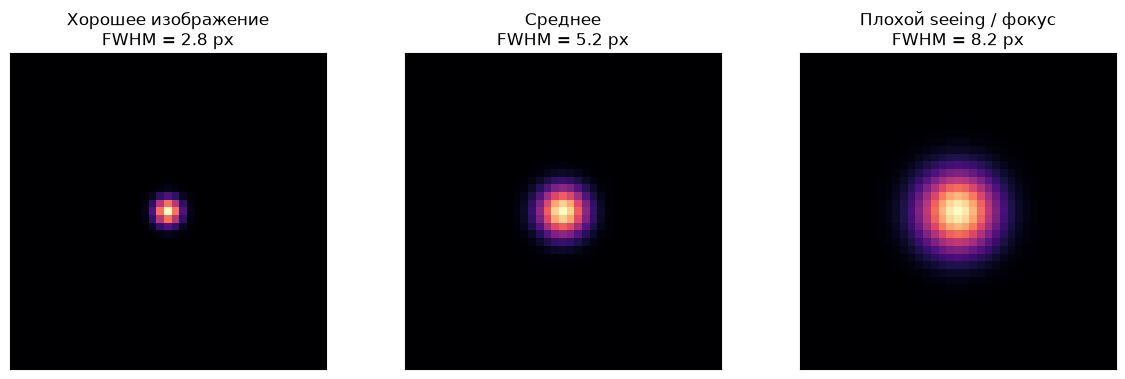

In [3]:
sigmas = [1.2, 2.2, 3.5]
labels = ["Хорошее изображение", "Среднее", "Плохой seeing / фокус"]

fig, axes = plt.subplots(1, 3, figsize=(12, 3.8))
for ax, current_sigma, label in zip(axes, sigmas, labels):
    current_psf = np.exp(
        -0.5 * ((x - center)**2 + (y - center)**2) / current_sigma**2
    )
    current_psf /= current_psf.sum()
    ax.imshow(current_psf, origin="lower")
    ax.set_title(f"{label}\nFWHM = {2.355*current_sigma:.1f} px")
    ax.set_xticks([])
    ax.set_yticks([])
plt.tight_layout()
plt.show()

PSF — не обязательно идеальная окружность или гауссиана. В реальном телескопе она может быть вытянутой, треугольной, иметь асимметричные крылья или меняться по полю. Поэтому полезно измерять её непосредственно по настоящим звёздам.

## 3. Из точек получается звёздное поле

Ниже слева находится условное «истинное небо»: каждая звезда — отдельная точка. Справа показано изображение после свёртки с PSF.

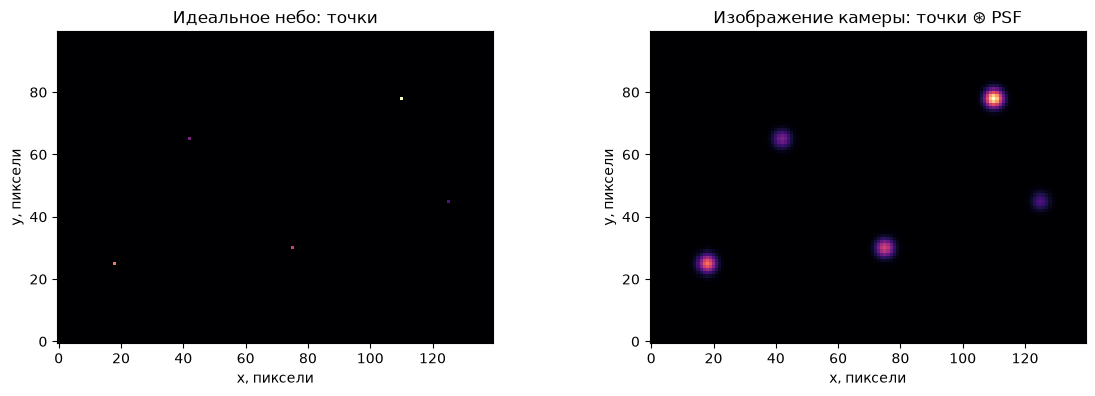

In [4]:
sky = np.zeros((100, 140))
stars = [
    (18, 25, 1.0),
    (42, 65, 0.5),
    (75, 30, 0.8),
    (110, 78, 1.4),
    (125, 45, 0.35),
]
for star_x, star_y, flux in stars:
    sky[star_y, star_x] = flux

field_psf_size = 25
py, px = np.indices((field_psf_size, field_psf_size))
pc = (field_psf_size - 1) / 2
field_psf = np.exp(-0.5 * ((px-pc)**2 + (py-pc)**2) / 2.0**2)
field_psf /= field_psf.sum()
camera_image = fftconvolve(sky, field_psf, mode="same")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(sky, origin="lower")
axes[0].set_title("Идеальное небо: точки")
axes[1].imshow(camera_image, origin="lower")
axes[1].set_title("Изображение камеры: точки ⊛ PSF")
for ax in axes:
    ax.set_xlabel("x, пиксели")
    ax.set_ylabel("y, пиксели")
plt.tight_layout()
plt.show()

## 4. Как PSF получают из звёзд

Одна звезда содержит шум. Поэтому берут много хороших несатурированных звёзд:

- вычитают фон;
- точно совмещают их центры;
- нормируют каждую звезду на одинаковый полный поток;
- усредняют.

Случайный шум уменьшается, а общая форма изображения остаётся.

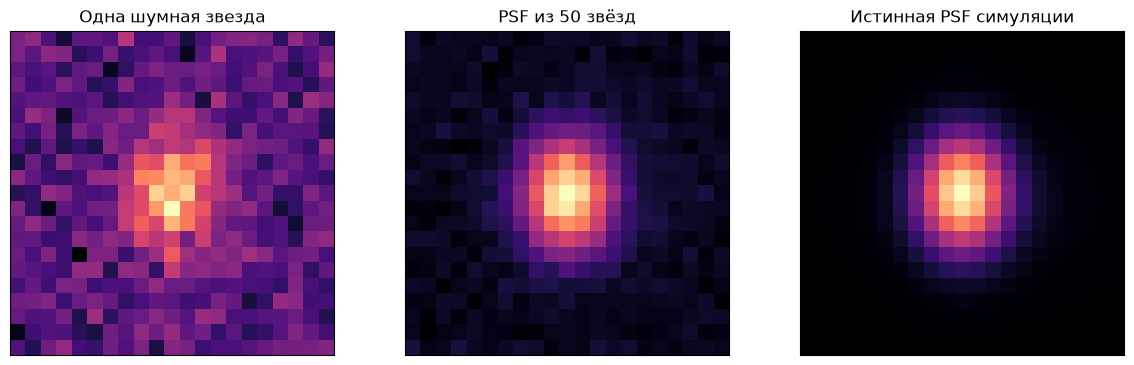

In [5]:
stamp_size = 21
sy, sx = np.indices((stamp_size, stamp_size))
stamp_center = (stamp_size - 1) / 2

# Немного несимметричная «настоящая» PSF.
true_psf = np.exp(
    -0.5 * (
        ((sx-stamp_center) / 2.0)**2
        + ((sy-stamp_center) / 2.6)**2
    )
)
true_psf += 0.08 * np.exp(
    -0.5 * (
        ((sx-stamp_center-1.5) / 4.0)**2
        + ((sy-stamp_center+0.5) / 3.0)**2
    )
)
true_psf /= true_psf.sum()

noisy_stars = []
for _ in range(50):
    flux = rng.uniform(8_000, 20_000)
    background = rng.uniform(800, 1200)
    noise = rng.normal(0, 45, true_psf.shape)
    noisy_stars.append(background + flux * true_psf + noise)

# Здесь центры синтетических звёзд уже совпадают.
normalized_stars = []
for star in noisy_stars:
    background = np.median(star[[0, -1], :])
    signal = star - background
    normalized_stars.append(signal / signal.sum())
measured_psf = np.mean(normalized_stars, axis=0)
measured_psf /= measured_psf.sum()

fig, axes = plt.subplots(1, 3, figsize=(12, 3.7))
axes[0].imshow(noisy_stars[0], origin="lower")
axes[0].set_title("Одна шумная звезда")
axes[1].imshow(measured_psf, origin="lower")
axes[1].set_title("PSF из 50 звёзд")
axes[2].imshow(true_psf, origin="lower")
axes[2].set_title("Истинная PSF симуляции")
for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])
plt.tight_layout()
plt.show()

Средняя PSF значительно чище одной звезды и восстанавливает заданную форму. В реальном ноутбуке Fredschaaf для одной PSF используются примерно 360–480 звёздных изображений.

## 5. PSF применяется к астероиду

PSF **строится по звёздам**, но затем используется как шаблон формы астероида. Если астероид за экспозицию почти не смещается, он является таким же точечным источником.

Модель имеет вид:

\[
I(x,y) = B + F\,\mathrm{PSF}(x-x_0, y-y_0),
\]

где `B` — фон, `F` — поток, а `(x₀,y₀)` — искомый центр астероида.

In [6]:
true_dx = 0.37
true_dy = -0.28
asteroid_flux = 12_000
background = 1_000
noise_sigma = 35

shifted_true_psf = shift(
    true_psf, (true_dy, true_dx), order=3, mode="constant", cval=0
)
weak_asteroid = (
    background
    + asteroid_flux * shifted_true_psf
    + rng.normal(0, noise_sigma, true_psf.shape)
)

def psf_residual(parameters):
    fitted_background, fitted_flux, dx, dy = parameters
    shifted_psf = shift(
        measured_psf, (dy, dx), order=3, mode="constant", cval=0
    )
    model = fitted_background + fitted_flux * shifted_psf
    return (model - weak_asteroid).ravel()

fit = least_squares(
    psf_residual,
    x0=[np.median(weak_asteroid), 10_000, 0, 0],
    bounds=([-np.inf, 0, -3, -3], [np.inf, np.inf, 3, 3]),
)
fitted_background, fitted_flux, fitted_dx, fitted_dy = fit.x
fitted_model = weak_asteroid + psf_residual(fit.x).reshape(weak_asteroid.shape)

print(f"Настоящий сдвиг: dx={true_dx:+.3f}, dy={true_dy:+.3f} пикселя")
print(f"Измеренный сдвиг: dx={fitted_dx:+.3f}, dy={fitted_dy:+.3f} пикселя")

Настоящий сдвиг: dx=+0.370, dy=-0.280 пикселя
Измеренный сдвиг: dx=+0.491, dy=-0.387 пикселя


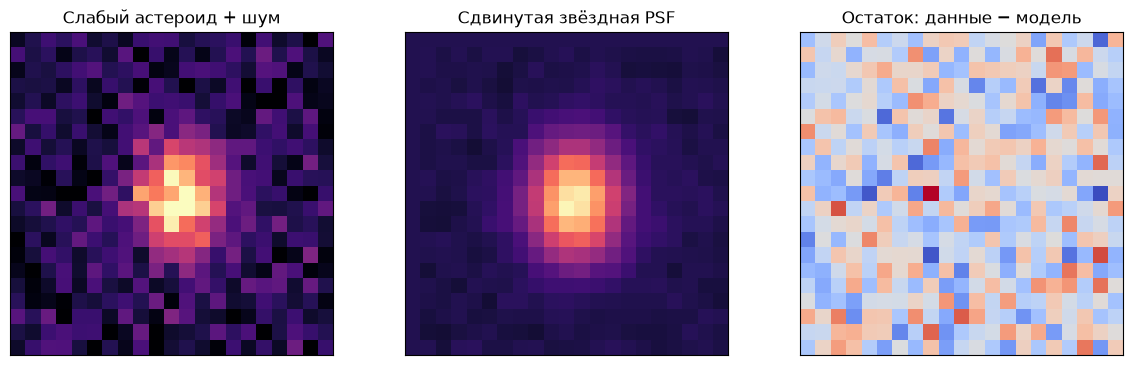

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.7))
residual_image = weak_asteroid - fitted_model
limits = np.percentile(weak_asteroid, (5, 99.5))

axes[0].imshow(weak_asteroid, origin="lower", vmin=limits[0], vmax=limits[1])
axes[0].set_title("Слабый астероид + шум")
axes[1].imshow(fitted_model, origin="lower", vmin=limits[0], vmax=limits[1])
axes[1].set_title("Сдвинутая звёздная PSF")
axes[2].imshow(residual_image, origin="lower", cmap="coolwarm")
axes[2].set_title("Остаток: данные − модель")
for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])
plt.tight_layout()
plt.show()

Хотя астероид шумный, фиксированная форма PSF позволяет определить его субпиксельный центр. Форма не угадывается по астероиду заново — она уже известна по звёздам.

## 6. Что происходит при движении между кадрами

За одну короткую экспозицию астероид Fredschaaf проходит очень мало. Но между последовательными кадрами его положение меняется. Если просто сложить кадры, объект растянется. Если перед сложением сдвинуть каждый кадр на ожидаемое движение астероида, его изображения совпадут.

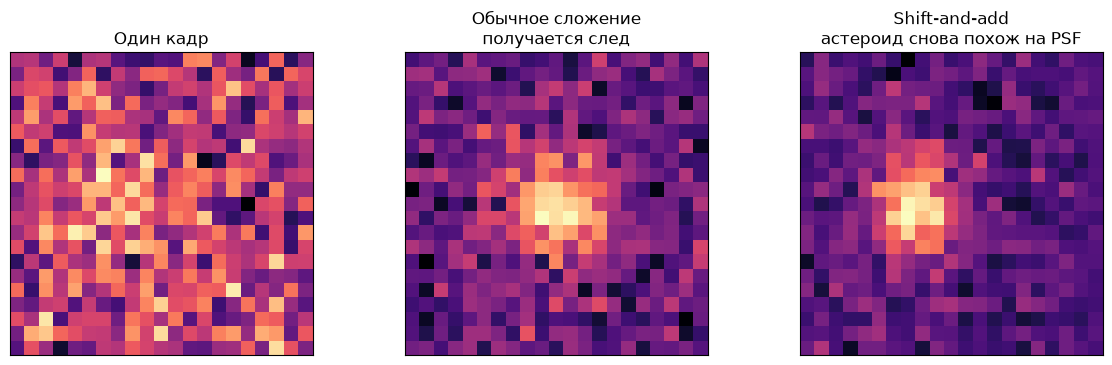

In [8]:
motion_frames = []
number_of_frames = 12
motion_per_frame = 0.45

for frame_number in range(number_of_frames):
    moving_source = shift(
        true_psf,
        (0, frame_number * motion_per_frame - 2.5),
        order=3,
        mode="constant",
        cval=0,
    )
    frame = 1000 + 2500 * moving_source + rng.normal(0, 35, true_psf.shape)
    motion_frames.append(frame)

ordinary_stack = np.mean(motion_frames, axis=0)
aligned_frames = [
    shift(
        frame - 1000,
        (0, -frame_number * motion_per_frame),
        order=3,
        mode="constant",
        cval=0,
    )
    for frame_number, frame in enumerate(motion_frames)
]
shift_and_add_stack = np.mean(aligned_frames, axis=0)

fig, axes = plt.subplots(1, 3, figsize=(12, 3.7))
axes[0].imshow(motion_frames[0], origin="lower")
axes[0].set_title("Один кадр")
axes[1].imshow(ordinary_stack, origin="lower")
axes[1].set_title("Обычное сложение\nполучается след")
axes[2].imshow(shift_and_add_stack, origin="lower")
axes[2].set_title("Shift-and-add\nастероид снова похож на PSF")
for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])
plt.tight_layout()
plt.show()

## 7. Как это связано с Fredschaaf

В основном анализе выполняется следующая последовательность:

1. по звёздам определяется астрометрическая система кадра;
2. плохие кадры исключаются по остаткам звёзд;
3. кадры сдвигаются по ожидаемому движению астероида;
4. каждые 20 исходных кадров образуют один стек;
5. по сотням звёзд тех же кадров строится эмпирическая PSF;
6. эта PSF сдвигается поверх астероида до наилучшего совпадения;
7. найденный сдвиг даёт координаты центра астероида.

Коротко:

\[
\boxed{\text{звёзды} \rightarrow \text{форма PSF} \rightarrow \text{центр астероида}}
\]

PSF не задаёт координату астероида и не использует его эфемериду. Она задаёт только ожидаемую **форму** точечного изображения.